# Computing embeddings, visualizing, and clustering

This notebook breaks down the components used in `polysemy_visualization.py` step by step.

We start with the computation of embeddings.

## Computing embeddings with minicons

BERT models read all words in a passage in parallel. They retrieve initial embeddings for each word in the passage, then repeatedly update each word's embeddings based on the embeddings of the other words around it.

More correctly, it's not *words* that receive embeddings, but *word pieces*. All LLMs break down words into word pieces. Frequent words stay at is, while infrequent ones may be broken up, for example plat-y-pus. (Why these particular tokens? That has to do with optimal compression of all the data the tokenization algorithm saw.)

The `minicons` package, https://github.com/kanishkamisra/minicons, computes embeddings for words in particular sentence contexts. If a word is broken into multiple word pieces, minicons averages over the embeddings of the word pieces to get a single embedding for the word -- that is standard practice. 



In [2]:
import torch
from minicons import cwe


# this is the BERT variant we're currently using
modelname = "bert-base-uncased"

# this is the object for computing embeddings
minicons_obj = cwe.CWE(modelname)

/Users/kerk/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Input to minicons: A list of sentence/target pairs.
# Each sentence/target pair is a tuple of two strings.
# The first is the sentence, the second the word form of the target
sentences = [("She drew a doodle around the corners of the document", "drew")]


In [4]:
# computing an embedding for "drew" in this sentence
# using the last layer (-1)
embs = minicons_obj.extract_representation(sentences, layer = -1)

In [5]:
embs

tensor([[ 5.6985e-01, -3.1687e-02,  2.7080e-01,  6.0358e-02, -2.9164e-01,
         -2.2457e-01, -5.5082e-02,  4.5097e-01, -4.8516e-01,  4.5639e-02,
          3.8464e-01, -1.0156e+00,  1.5227e-01,  5.6374e-01, -2.3394e-01,
          5.9100e-01, -2.2850e-01,  1.2498e-01, -7.3153e-01, -3.6450e-01,
          4.6830e-01,  2.0976e-01, -2.0890e-01,  9.4861e-01,  1.9096e-01,
         -5.7923e-01,  3.4443e-01, -4.0376e-01, -3.5652e-01, -2.0046e-01,
          3.0370e-01, -5.8283e-02,  6.7424e-01, -3.8585e-01,  3.1035e-01,
          4.7397e-01,  2.3683e-01, -2.1564e-01, -1.3308e+00, -2.3230e-01,
         -3.7936e-01, -7.8521e-01,  2.5173e-01,  7.3936e-01,  1.2180e+00,
          4.4668e-01, -1.7611e-01,  2.8504e-01,  8.5061e-01,  4.6520e-01,
         -2.3869e-01,  7.3852e-01,  1.0426e+00,  1.1820e-01, -9.9655e-01,
          1.7357e+00,  4.8431e-01, -1.7670e-01, -4.2981e-01, -3.4844e-01,
          1.6470e-01,  3.9368e-01, -8.1752e-01,  5.0263e-01,  1.0180e-01,
          7.7417e-02, -7.6331e-03,  5.

In [6]:
# Minicons returns a pytorch tensor
type(embs)

torch.Tensor

In [7]:
# We get an array with one row (one embedding).
# In BERT base, it has 768 dimensions.
embs.shape

torch.Size([1, 768])

In [8]:
# Here is how you give Minicons two sentences at once.
# Note: Don't give it too many sentences at once, 
# or it will crash the kernel. 
# I usually give it sentences in batches of 100,
# then concatenate the outputs from all batches.
sentences = [("She drew her sword", "drew"),
            ("Let me draw you a picture", "draw")]

In [9]:
embs  = minicons_obj.extract_representation(sentences, layer = -1)

In [10]:
# Two sentences of input, two rows of output
embs.shape

torch.Size([2, 768])

In [11]:
# Here is what happens when we use BERT large instead
minicons_large_obj = cwe.CWE('bert-large-uncased')

In [12]:
embs  = minicons_large_obj.extract_representation(sentences, layer = -1)

In [13]:
# in BERT large, we have 1024 dimensions per embedding
embs.shape

torch.Size([2, 1024])

My impression is that we can often get better results if we average over multiple embedding layers. Here is how to do that with minicons.

In [14]:
# we can ask the minicons object 
# how many layers the LLM has that it uses.
# Here we ask the one with bert-base-uncased
minicons_obj.layers

12

In [15]:
# Here is how to access the last 4 layers
list(range(minicons_obj.layers + 1))[-4:]

[9, 10, 11, 12]

In [16]:
# here is how to use the last 4 layers

# extract embeddings from the last four layers
lastfour = list(range(minicons_obj.layers + 1))[-4:]
embs = minicons_obj.extract_representation(sentences, layer = lastfour)

# and average over them
avg_embs = torch.mean(torch.stack(embs), dim=0) 

In [17]:
print("original embeddings: a list of length", len(embs), ", each entry is a matrix of shape", embs[0].shape)
print("and here is what we get after averaging: ", avg_embs.shape)

original embeddings: a list of length 4 , each entry is a matrix of shape torch.Size([2, 768])
and here is what we get after averaging:  torch.Size([2, 768])


## Dimensionality reduction and visualization

To visualize embeddings, we need to reduce their dimensionality, as 768 dimensions are too much to picture. We use *dimensionality reduction* methods to boil down the embeddings to two dimensions in a way that retains relative distances between points as much as possible. 

As demo data, we use the COCA occurrences of "draw". 

In [18]:
import pandas as pd
import numpy as np

# the following code is to avoid this warning when running t-sne:
# "huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
# To disable this warning, you can either:
# - Avoid using `tokenizers` before the fork if possible
# 	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false) 
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [19]:
targetlemma = "draw"
inputdir = "data"
inputfilename = os.path.join(inputdir, targetlemma + ".csv")

df = pd.read_csv(inputfilename)
df.head()

,Unnamed: 0,tgt,sent,meta_file,meta_indices
0,0,drew,you must give them a sign to show them you are...,text_acad_1990.txt,"(21956428, 21956565)"
1,1,drew,<p> In the process of refining their new sense...,text_acad_1991.txt,"(6885982, 6886400)"
2,2,drew,"<p> At the end of World War II , when the Unit...",text_acad_1992.txt,"(4304831, 4305182)"
3,3,drew,"keeping his back to me , pushed him forward do...",text_acad_1994.txt,"(325341, 325726)"
4,4,draw,"For as noted in the beginning , great art tran...",text_acad_1994.txt,"(16779384, 16779549)"


We use minicons to compute embeddings for all the occurrences of "draw". The sentences are in column 'sent', the targets in column 'tgt'. We need to work in batches, so that minicons doesn't crash the kernel.

I'm using layer 8 for now to keep things simple.

In [20]:
embs = [ ]
batchsize = 100

for startix in range(0, len(df), batchsize):

    # df is the pandas data frame containing the "draw" data.
    # to_dict("records") turns each row in the data frame into a dictionary 
    # where the column labels are keys and the column contents are values.
    # We extract data frames rows from start index to start index + batchsize,
    # and grab sentence and target word for each 
    sentences = [ (row["sent"], row["tgt"]) \
                  for row in df.iloc[startix:startix + batchsize].to_dict( "records") ]
    
    print("Input to minicons: Here is one example sentence/target pair", sentences[0])

    currentbatch_embs = minicons_obj.extract_representation(sentences, layer = 8)

    # transform from torch tensors to numpy arrays
    currentbatch_embs = currentbatch_embs.detach().numpy()

    # and store the current batch
    embs.append(currentbatch_embs)

# combine all batches into a single matrix
embs = np.concatenate(embs, axis = 0)

Input to minicons: Here is one example sentence/target pair ('you must give them a sign to show them you are from God . " Ali Asghar then drew out his dry tongue and slowly licked his parched lips .', 'drew')
Input to minicons: Here is one example sentence/target pair ('" <p> In his loss to Falla , at least , Christian exhibited little of the volatile temper for which his brother has drawn criticism ; Ryan threw his racket and spiked a ball in anger in his first-round loss Sunday .', 'drawn')
Input to minicons: Here is one example sentence/target pair ('Some people took their allotted time and became world-famous artists and had raucous affairs and still made a house so particular and grand that a replication drew crowds . # Out in the Peggy Guggenheim Rose Garden , coral and white and lemon and violet and scarlet petals sifted , hybrids someone had dreamt up , giddily named .', 'drew')
Input to minicons: Here is one example sentence/target pair ('CUTLINE : LIVING COLOUR : Singer Corey

Now we reduce the dimensionality of the embeddings to two using t-sne:

In [21]:
from sklearn.manifold import TSNE

twodim = TSNE(n_components = 2, random_state = 0).fit_transform(embs)

/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/kerk/

Here is an initial visualization. It's not particularly useful because we can't say which dot is which.

In [22]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.cm as cm

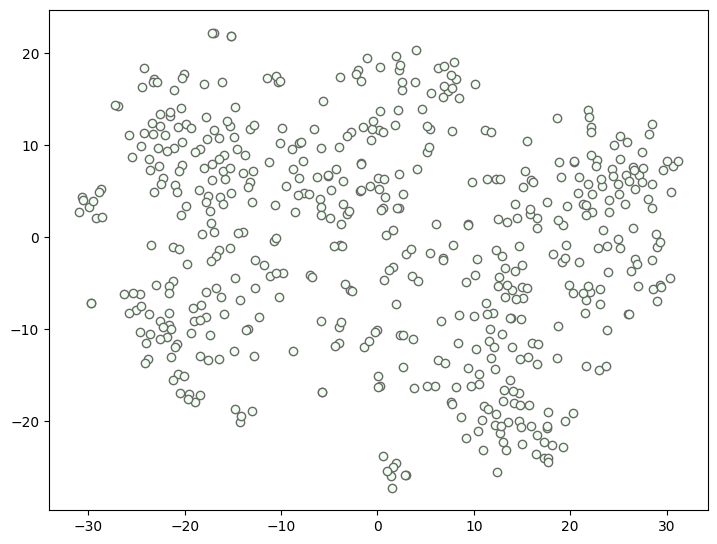

In [23]:
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)

# a scatter plot of the two-dimensional points
ax.scatter(twodim[:,0], twodim[:,1], edgecolors="dimgray", c="honeydew");

### Seeing texts when we hover over points

To make the visualization useful, we need to be able to see the particular instance of "draw" when we hover over a point in the picture. 

There are multiple python packages that support hovering, but it turned out that not all of them were compatible with all the other things I wanted to be able to put in the graph, so I chose mplcursors.

Showing the whole sentence when we hover over a point is too much, because the sentences can be long. So we cut each sentence down to a sentence snippet centered on the target word. 


In [24]:
sentence_snippets = [ ]
windowsize = 5
    
for row in df.to_dict("records"):
    words = row["sent"].split()

    # sanity check
    if row["tgt"] not in words:
        # store the original sentence in its entirety
        sentence_snippets.append(" ".join(words))
        continue
    
    # determine the index of the target word
    targetindex = words.index(row["tgt"])
    
    # window of 5 words left and right of the target, 
    # but don't go below 0 or above the length of the sentence
    snippet_start = max(0, targetindex - windowsize)
    snippet_end = min(snippet_start + 2 * windowsize + 1, len(words))
    
    # make the snippet, as a string
    snippet = words[snippet_start : snippet_end]
    sentence_snippets.append(" ".join(snippet))


In [25]:
import mplcursors

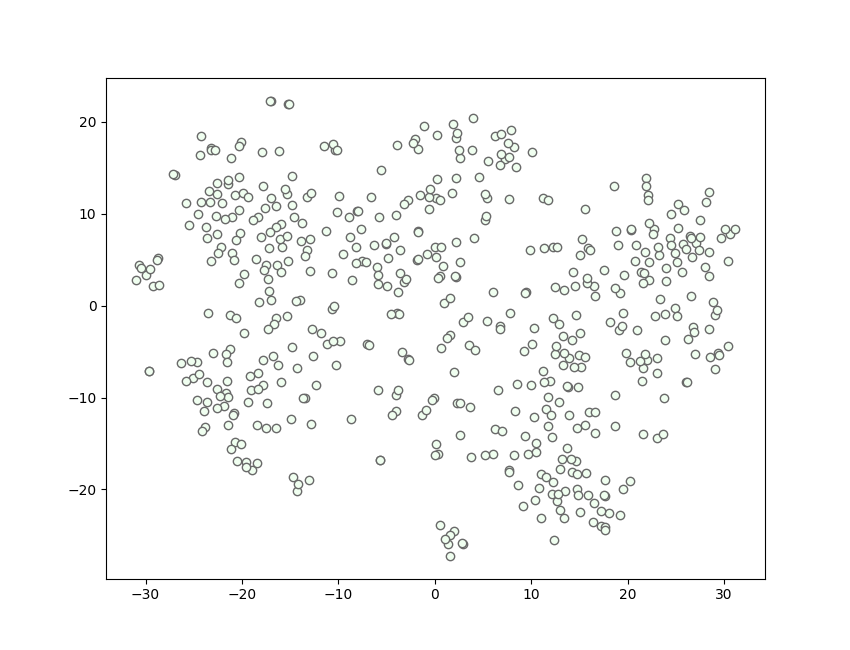

In [26]:
%matplotlib widget

# now we visualize again, with extra code to support the hovering
# set up the canvas
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)


# add a scatter plot of the two-D embeddings
scatter = ax.scatter(twodim[:,0], twodim[:,1], edgecolors="dimgray", c="honeydew")
cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(sentence_snippets[i])
    sel.annotation.set_fontsize(8)
    sel.annotation.set_fontfamily("DejaVu Sans")
    sel.annotation.set_color("black")
    
    box = sel.annotation.get_bbox_patch()
    box.set(fc="white", lw=0.8, alpha=0.9)  # fc=facecolor, ec=edgecolor
    box.set_boxstyle("round,pad=0.25")

    # sel.annotation.get_bbox_patch().set_visible(False)

plt.show()


## Clustering, and adding cluster colors to the plot

Clustering means automatically grouping. We can cluster instances of "draw" by their embeddings. In this demo, I use k-means, a very simple clustering method, which however needs the number of clusters as an input. 



In [27]:
from sklearn.cluster import KMeans

numclusters = 7

# standard way to use machine learning from scikit learn:
# first make an object specific to the machine learning method
kmeans = KMeans(n_clusters=numclusters, random_state=0, n_init="auto")
# then fit it to the data
kmeans.fit(embs)

# done. now we can read off the results:
# the KMeans object now has a list of labels, one for
# each data point. The label says what cluster the data point goes to
clusterlabels = kmeans.labels_


/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kerk/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [28]:
from collections import defaultdict

# now we can pair the labels with the sentences to see which sentences got which label
# let's make a list of (sentence, target) pairs,
# this time for the whole dataset
sentences = [ (row["sent"], row["tgt"]) for row in df.to_dict( "records") ]
# pair up labels with sentences, 
# then turn this into a dictionay where the label is the key
# and the sentences are the values
cluster_sentences = defaultdict(list)
for clusterlabel, sent in zip(clusterlabels, sentences):
    cluster_sentences[ clusterlabel ].append(sent)

Now we can print the sentences that go with each cluster. Let's print ten for each.

In [29]:
sent_to_print = 10

for clusterlabel, sents in sorted(cluster_sentences.items()):
    print("--- cluster ", clusterlabel, "------")
    for s in sents[:sent_to_print]:
        print("\n", s)
    print()

--- cluster  0 ------

 ("keeping his back to me , pushed him forward down the road about fifty yards -- he all the while endeavouring to turn round &; strike me , &; raging &; cursing , which drew out several neighbours ; at length , when I had got him to where he was Quarter 'd , which was very quickly done , we were met at the Gate by the Master of The Fox Inn ( who is the proprietor of my Cottage ) , &;", 'drew')

 ('" <p> It is not just for their " polyphiloprogenitive " tendencies , however , that various creatures draw Beeton \'s attention , but for their capacity to break down the very boundaries by which meaning and culture are secured , boundaries which Beeton has pledged herself and the Victorian household to defend .', 'draw')

 ('In this " desecration of idols , " the Arab leaders are brought one by one to be tossed into the fire 79 and burned alive , as punishment for their betrayal of the people of Tal al-Za\'tar and other crimes : PREFORMATTED TABLE <p> This is repeated

Here is how to add cluster labels into the graph: The scatterplot command has an optional parameter "c" that takes in a list of color indices, one for each datapoint to plot. Python's matplotlib comes with several color maps that the color indices can map into: https://matplotlib.org/stable/users/explain/colors/colormaps.html I'm going to use viridis. you can change the whole color scheme of the graph just by putting a different value for the parameter `cmap`. 

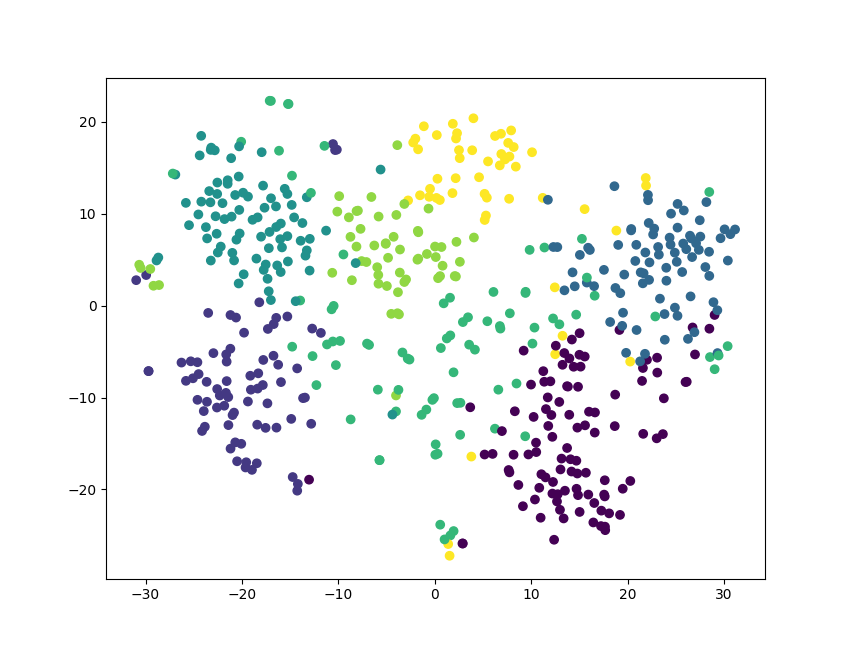

In [30]:
%matplotlib widget

# now we visualize again, with extra code to support the hovering
# set up the canvas
fig, ax =  plt.subplots()
fig.set_size_inches(8.5, 6.5)


# add a scatter plot of the two-D embeddings
# NEW STUFF HERE, parameters c and cmap
scatter = ax.scatter(twodim[:,0], twodim[:,1], c=clusterlabels, cmap = "viridis")
cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_add(sel):
    i = sel.index
    sel.annotation.set_text(sentence_snippets[i])
    sel.annotation.set_fontsize(8)
    sel.annotation.set_fontfamily("DejaVu Sans")
    sel.annotation.set_color("black")
    
    box = sel.annotation.get_bbox_patch()
    box.set(fc="white", lw=0.8, alpha=0.9)  # fc=facecolor, ec=edgecolor
    box.set_boxstyle("round,pad=0.25")

    # sel.annotation.get_bbox_patch().set_visible(False)

plt.show()
